In [1]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd

from itertools import product

#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

In [2]:
is_stratified_g = False

# GENERAL TEST FEATURES

In [3]:
global_experiment_list = {}

In [4]:
struct_features = ['height']

sentinel_bands  = ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2']
sentinel_indices = ['NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE']

top_spectral_1  = ['height', 'EVI', 'NIR', 'NBR', 'SWIR1']
top_spectral_2  = ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1']

redband_1       = ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2']
redband_2       = ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2']

ineraction_terms = ['height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']

useful_categorical = []# ['plot_id']

target = 'plant_AGB_kg'

gen_features_list = [struct_features,
                     struct_features + ineraction_terms,
                 
                     #sentinel_bands,
                     #sentinel_bands + ineraction_terms,
                 
                     #sentinel_indices,
                     #sentinel_indices + ineraction_terms,
                 
                     #sentinel_bands + sentinel_indices,
                     #sentinel_bands + sentinel_indices + ineraction_terms,
                 
                     #struct_features + sentinel_bands + sentinel_indices,
                     #struct_features + sentinel_bands + sentinel_indices + ineraction_terms,

                     #top_spectral_1,
                     #top_spectral_1 + ineraction_terms,
                 
                     #top_spectral_2,
                     #top_spectral_2 + ineraction_terms,
                 
                     #redband_1,
                     #redband_1 + ineraction_terms,
                 
                     #redband_2,
                     #redband_2 + ineraction_terms
                    ]

test_cv = 5
#test_cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

# DOWNLOAD SENTINEL-AGB DATA

In [5]:
SENTINEL_DATA_CSV        = "../../DATA/AGB_DATA/Merged_Data/Sentinel_AGB/AGB_SENTINEL_CANOPY.csv"
#SENINEL_MISSING_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/Sentinel_AGB/AGB_VAL_EO_SENTINEL.csv"

sentinel_df = pd.read_csv(SENTINEL_DATA_CSV)
print(sentinel_df.shape)
sentinel_df.columns

(8774, 34)


Index(['dataset', 'plot_id', 'start_date', 'end_date', 'latitude', 'longitude',
       'diameter', 'height', 'species', 'plant_AGB_kg', 'capture_start',
       'capture_end', 'sentinel_time', 'Blue', 'Green', 'Red', 'RE1', 'RE2',
       'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'cloud_threshold_used',
       'simard_height_m', 'tandemx_height_m'],
      dtype='object')

In [6]:
assert len(sentinel_df["simard_height_m"].head())
assert len(sentinel_df["tandemx_height_m"].head())

In [7]:
sentinel_df['dataset'].unique()

array(['ElSalvador', 'Panama-Chirqui_2', 'CostaRica-Nicoya',
       'CostaRica-Sierpe', 'Belige', 'Panama-Chirqui_1',
       'Honduras-Blanca', 'Brazil-Mangue', 'Brazil-Furo_Do_Chato',
       'Brazil-Manguezal', 'Brazil-Maruipe', 'Brazil-AcarauBoca',
       'Brazil-BocaGrande', 'Brazil-Barreto', 'Brazil-Salinas',
       'Brazil-FuroGrande', 'Brazil-Caetano'], dtype=object)

### Select features

In [8]:
non_feature_cols = [
    'plant_AGB_kg',        # Target variable
    'dataset',             # metadata
    'sentinel_time',       # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',            # coordinate
    'longitude',           # coordinate
    'diameter',            # Allometric
    'height',               # Allometric
    'cloud_threshold_used',
    'start_date'
]

useful_categorical = ['plot_id', 'species']

target = 'plant_AGB_kg'

feature_cols = [c for c in sentinel_df.columns if c not in non_feature_cols]

## EXTRACT BELIGE DATASET

In [9]:
belige_df = sentinel_df[sentinel_df['dataset'] == 'Belige'].copy()
assert len(belige_df['simard_height_m'].head())
assert len(belige_df['tandemx_height_m'].head())

X_belige = belige_df[feature_cols].copy()

# Select TANDEMX
X_belige = X_belige.rename({'tandemx_height_m': 'height'}, axis=1)
X_belige = X_belige.drop(columns=['simard_height_m'])

# Select SIMARD
#X_belige = X_belige.rename({'simard_height_m': 'height'}, axis=1)
#X_belige = X.drop(columns=['tandemx_height_m'])

y_belige  = belige_df[target]

test_cv = 5

In [10]:
X_belige.columns

Index(['plot_id', 'species', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3',
       'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height'],
      dtype='object')

### Interaction terms

In [11]:
# height × EVI — the most promising. Height captures structural biomass, EVI captures canopy greenness.
# Their product approximates a "green volume" index and may capture the AGB signal better than either alone.
X_belige['height_x_EVI'] = X_belige['height'] * X_belige['EVI']

#height × NIR — NIR reflectance is strongly tied to canopy density.
# Combined with height it approximates canopy biomass density.
X_belige['height_x_NIR'] = X_belige['height'] * X_belige['NIR']

#height × NDRE1 — red-edge is sensitive to chlorophyll content.
# For mangroves, chlorophyll × height is a reasonable proxy for woody biomass.
X_belige['height_x_NDRE1'] = X_belige['height'] * X_belige['NDRE1']

In [12]:
X_belige.columns

Index(['plot_id', 'species', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3',
       'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height',
       'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'],
      dtype='object')

## Show correlations

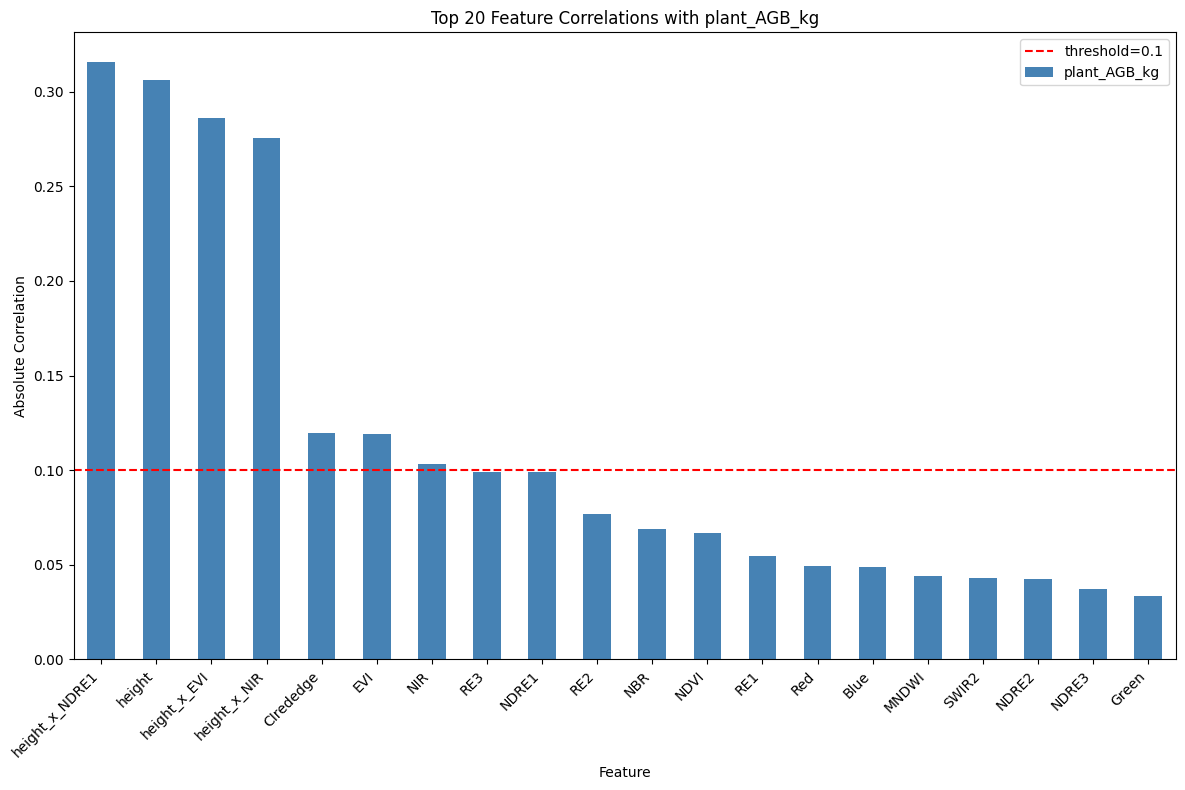

height_x_NDRE1    0.315565
height            0.305997
height_x_EVI      0.285951
height_x_NIR      0.275702
CIrededge         0.119717
EVI               0.119078
NIR               0.103383
RE3               0.099264
NDRE1             0.098902
RE2               0.076811
NBR               0.068840
NDVI              0.066806
RE1               0.054646
Red               0.049271
Blue              0.048902
MNDWI             0.044189
SWIR2             0.043206
NDRE2             0.042639
NDRE3             0.037197
Green             0.033607
Name: plant_AGB_kg, dtype: float64


In [13]:
numerical_cols = get_numerical_cols(X_belige)
target_corr = plot_correlation_matrix(X_belige[numerical_cols],
                                      y_belige,
                                      top_n=20)
print(target_corr)

## Create plot-level groups for Belige data

In [14]:
n_plots = X_belige['plot_id'].nunique()
print(f"Belige : {len(X_belige)} rows, {n_plots} plots")

Belige : 3880 rows, 59 plots


In [15]:
# Retain the groups/plot_id for splitting the data based on groups.
if 'plot_id' in X_belige.columns:
    plot_groups_belige = X_belige['plot_id'].copy()
    X_belige = X_belige.drop(columns=['plot_id'])

site_groups_belige = plot_groups_belige.map(lambda x: x.rsplit('_', maxsplit=1)[0])

near_zero_sites_belige, high_agb_sites_belige,\
    near_zero_plots_belige, high_agb_plots_belige = get_low_and_high_agb_plots(y_belige,
                                                                               plot_groups_belige)

grp_belige = GROUP_INFO(near_zero_sites_belige, high_agb_sites_belige,
                        near_zero_plots_belige, high_agb_plots_belige,
                        groups=plot_groups_belige,
                        cv=test_cv)

High-AGB threshold  : 104.49 kg
Near-zero threshold : 0.004134

Near-zero variance plots:
  Big Creek_1               : log var = 0.000036
  Big Creek_4               : log var = 0.000032
  Frenchman Caye_1          : log var = 0.000753
  Frenchman Caye_2          : log var = 0.000381
  Frenchman Caye_3          : log var = 0.000693
  Frenchman Caye_4          : log var = 0.001306
  Frenchman Caye_5          : log var = 0.001283
  Frenchman Caye_6          : log var = 0.000158
  Shipstern Lagoon_1        : log var = 0.001064
  Shipstern Lagoon_3        : log var = 0.000232
  Shipstern Lagoon_4        : log var = 0.000113
  Shipstern Lagoon_5        : log var = 0.000052
  Shipstern Lagoon_6        : log var = 0.000135

High-AGB plots:
  Channel Caye_1            : max AGB = 310.9 kg
  Channel Caye_2            : max AGB = 206.4 kg
  Channel Caye_3            : max AGB = 427.2 kg
  Channel Caye_4            : max AGB = 237.6 kg
  Channel Caye_5            : max AGB = 170.4 kg
  Channel C

In [16]:
global_experiment_list = {}
experiment_registry = []

In [17]:
linear_models = ["linear", "ridge", "lasso", "elasticnet"]

### BELIGE DATA. LINEAR REGRESSION. NO GROUPS

In [18]:
%run Model_functions.ipynb
lin_belige_no_groups = {}

run_experiment(X_belige, y_belige,
               is_groups=False, group_info=grp_belige,
               features_list=gen_features_list,
               model_type="linear",
               linear_variants=linear_models,
               is_grid=False,
               is_stratified=is_stratified_g,
               exp_registry=experiment_registry,
               exp_total_list=global_experiment_list,
               exp_by_category=lin_belige_no_groups,
               dataset="SENTINEL+TANDEMX",
               display=False)


[1/8]

RUN: Dataset: SENTINEL+TANDEMX, Model: LINEAR REGRESSION, Grouping? No, Hypertuned? No, Features: ['height']
 Test R²     : 0.0131
 Test RMSE   : 16.75 kg
 Train R² (log scale): 0.2200
 Train R² (orig scale): 0.0166
 Train RMSE  : 16.59 kg
 Num rows    : 3104
 Num Features: 1

 Cross-validation ---
CV R² mean: 0.2180
CV R² std : 0.0168
CV scores : [0.23  0.221 0.186 0.233 0.221]
 EVALUATION: 

Test set:
  R²   : 0.013
  RMSE : 16.75 kg

 ✅ Test R² is positive (0.013)

Regular CrossValidation:
  Mean   : 0.218
  Std    : 0.017
  Scores : [0.23  0.221 0.186 0.233 0.221]
 ✅ CV mean is positive (0.218)
  ✅ Train/test R² gap acceptable (gap: 0.003)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[2/8]

RUN: Dataset: SENTINEL+TANDEMX, Model: RIDGE REGRESSION, Grouping? No, Hypertuned? No, Features: ['height']
 Test R²     : 0.0166
 Test RMSE   : 16.72 kg
 Train R² (log scale): 0.2200
 Train R² (orig scale): 0.0181
 Train RMSE  : 16.58 kg
 Num rows

In [19]:
tab_df = tabulate_results(lin_belige_no_groups, acceptable_only=True)

Showing 8 acceptable experiments only


,Dataset,Model,Num features,Features,Groups?,Tuned?,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV-Test Gap,-ve Folds,Group CV scores,verdict
0,,LINEAR REGRESSION,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",No,No,0.0873,16.11,0.051,16.3,0.2583,0.0209,"[0.261, 0.26, 0.22, 0.284, 0.266]",,,,,,✅ ACCEPTABLE
1,,RIDGE REGRESSION,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",No,No,0.086,16.12,0.0506,16.31,0.2583,0.0209,"[0.261, 0.26, 0.22, 0.284, 0.265]",,,,,,✅ ACCEPTABLE
2,,LASSO REGRESSION,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",No,No,0.0632,16.32,0.0415,16.38,0.2553,0.024,"[0.261, 0.264, 0.21, 0.281, 0.261]",,,,,,✅ ACCEPTABLE
3,,ELASTICNET REGRESSION,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",No,No,0.0649,16.3,0.0422,16.38,0.2549,0.0241,"[0.261, 0.264, 0.209, 0.281, 0.261]",,,,,,✅ ACCEPTABLE
4,,LINEAR REGRESSION,1,['height'],No,No,0.0131,16.75,0.0166,16.59,0.218,0.0168,"[0.23, 0.221, 0.186, 0.233, 0.221]",,,,,,✅ ACCEPTABLE
5,,RIDGE REGRESSION,1,['height'],No,No,0.0166,16.72,0.0181,16.58,0.218,0.0167,"[0.229, 0.221, 0.186, 0.233, 0.221]",,,,,,✅ ACCEPTABLE
6,,LASSO REGRESSION,1,['height'],No,No,0.0153,16.73,0.0175,16.59,0.218,0.0167,"[0.23, 0.221, 0.186, 0.233, 0.221]",,,,,,✅ ACCEPTABLE
7,,ELASTICNET REGRESSION,1,['height'],No,No,0.0151,16.73,0.0174,16.59,0.218,0.0166,"[0.23, 0.221, 0.186, 0.233, 0.221]",,,,,,✅ ACCEPTABLE


### BELIGE DATA. PLOT GROUPS. ALL ROWS. LINEAR REGRESSION

In [20]:
%run Model_functions.ipynb
lin_belige_groups = {}

run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=gen_features_list,
               model_type="linear",
               linear_variants=linear_models,
               is_grid=False,
               is_stratified=is_stratified_g,
               exp_registry=experiment_registry,
               exp_total_list=global_experiment_list,
               exp_by_category=lin_belige_groups,
               dataset="SENTINEL+TANDEMX",
               display=False)


[1/8]

RUN: Dataset: SENTINEL+TANDEMX, Model: LINEAR REGRESSION, Grouping? Yes, Hypertuned? No, Features: ['height']
 Test R²     : 0.1515
 Test RMSE   : 4.25 kg
 Train R² (log scale): 0.2551
 Train R² (orig scale): -0.1772
 Train RMSE  : 20.15 kg
 Num rows    : 3100
 Num Features: 1

 Cross-validation ---
CV R² mean: 0.1855
CV R² std : 0.2018
CV scores : [-0.029  0.568  0.095  0.134  0.16 ]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2296
Grouped CV R² std : 0.2175
Grouped CV scores : [-0.108  0.081  0.116 -0.026  0.407  0.535  0.582  0.187  0.21   0.313]
 EVALUATION: 

Test set:
  R²   : 0.152
  RMSE : 4.25 kg

 ✅ Test R² is positive (0.152)

Regular CrossValidation:
  Mean   : 0.185
  Std    : 0.202
  Scores : [-0.029  0.568  0.095  0.134  0.16 ]
 ✅ CV mean is positive (0.185)

Grouped CrossValidation:
  Big Creek_5          :  -0.108  ⚠️  fold contamination — Channel Caye_1 in same fold
  Frenchman Caye_6     :   0.081  ✅
  Frenchman Caye_3     :   0.116  ✅
  Big Creek_3  

In [21]:
tab_df = tabulate_results(lin_belige_groups, acceptable_only=True)

Showing 8 acceptable experiments only


,Dataset,Model,Num features,Features,Groups?,Tuned?,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV-Test Gap,-ve Folds,Group CV scores,verdict
0,,LASSO REGRESSION,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",Yes,No,0.1518,4.25,0.0541,18.06,0.194,0.2169,"[-0.038, 0.602, 0.083, 0.176, 0.146]",0.2391,0.1952,0.0873,"2 (Big Creek_5, Big Creek_3)","[-0.045, 0.134, 0.121, -0.007, 0.339, 0.553, 0.547, 0.201, 0.214, 0.335]",⚠️ MARGINAL — positive metrics but concerns
1,,LINEAR REGRESSION,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",Yes,No,0.2205,4.08,0.0545,18.06,0.183,0.218,"[-0.064, 0.591, 0.098, 0.159, 0.13]",0.2378,0.1876,0.0173,1 (Big Creek_5),"[-0.033, 0.142, 0.105, 0.006, 0.319, 0.558, 0.518, 0.215, 0.213, 0.334]",✅ ACCEPTABLE
2,,ELASTICNET REGRESSION,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",Yes,No,0.1383,4.28,0.0544,18.06,0.1945,0.208,"[-0.035, 0.58, 0.08, 0.201, 0.147]",0.2376,0.1936,0.0994,"2 (Big Creek_5, Big Creek_3)","[-0.04, 0.134, 0.121, -0.017, 0.339, 0.552, 0.535, 0.201, 0.215, 0.335]",⚠️ MARGINAL — positive metrics but concerns
3,,RIDGE REGRESSION,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",Yes,No,0.1808,4.18,0.052,18.08,0.1966,0.2185,"[-0.055, 0.6, 0.089, 0.183, 0.167]",0.2369,0.1928,0.0561,"2 (Big Creek_5, Big Creek_3)","[-0.04, 0.137, 0.118, -0.011, 0.33, 0.558, 0.53, 0.197, 0.216, 0.334]",⚠️ MARGINAL — positive metrics but concerns
4,,LINEAR REGRESSION,1,['height'],Yes,No,0.1515,4.25,-0.1772,20.15,0.1855,0.2018,"[-0.029, 0.568, 0.095, 0.134, 0.16]",0.2296,0.2175,0.0781,"2 (Big Creek_5, Big Creek_3)","[-0.108, 0.081, 0.116, -0.026, 0.407, 0.535, 0.582, 0.187, 0.21, 0.313]",⚠️ MARGINAL — positive metrics but concerns
5,,RIDGE REGRESSION,1,['height'],Yes,No,0.1536,4.25,-0.0952,19.43,0.182,0.1966,"[-0.027, 0.554, 0.089, 0.134, 0.16]",0.2253,0.2148,0.0717,"2 (Big Creek_5, Big Creek_3)","[-0.108, 0.081, 0.109, -0.026, 0.399, 0.526, 0.577, 0.184, 0.206, 0.307]",⚠️ MARGINAL — positive metrics but concerns
6,,LASSO REGRESSION,1,['height'],Yes,No,0.1529,4.25,-0.1273,19.72,0.1871,0.1968,"[-0.02, 0.56, 0.092, 0.145, 0.157]",0.2238,0.2092,0.071,"2 (Big Creek_5, Big Creek_3)","[-0.107, 0.081, 0.112, -0.023, 0.403, 0.53, 0.539, 0.185, 0.208, 0.31]",⚠️ MARGINAL — positive metrics but concerns
7,,ELASTICNET REGRESSION,1,['height'],Yes,No,0.1534,4.25,0.0088,18.49,0.1761,0.1844,"[-0.023, 0.524, 0.093, 0.144, 0.142]",0.2153,0.2077,0.062,"2 (Big Creek_5, Big Creek_3)","[-0.107, 0.08, 0.093, -0.023, 0.38, 0.503, 0.561, 0.175, 0.198, 0.294]",⚠️ MARGINAL — positive metrics but concerns


### BELIGE DATA. NO GROUPS. ALL ROWS. RANDOM FOREST (Hyper parameter tuning: NO)

In [22]:
%run Model_functions.ipynb

rf_belige_no_grps = {}

run_experiment(X_belige, y_belige,
               is_groups=False, group_info=grp_belige,
               features_list=gen_features_list,
               model_type="rf",
               is_grid=False,
               is_stratified=is_stratified_g,
               exp_registry=experiment_registry,
               exp_total_list=global_experiment_list,
               exp_by_category=rf_belige_no_grps,
               dataset="SENTINEL+TANDEMX",
               display=False)


[1/2]
 EVALUATION: 

Test set:
  R²   : 0.133
  RMSE : 15.70 kg

 ✅ Test R² is positive (0.133)

Regular CrossValidation:
  Mean   : 0.371
  Std    : 0.031
  Scores : [0.427 0.343 0.344 0.363 0.378]
 ✅ CV mean is positive (0.371)
  ✅ Train/test R² gap acceptable (gap: 0.054)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[2/2]
 EVALUATION: 

Test set:
  R²   : 0.133
  RMSE : 15.70 kg

 ✅ Test R² is positive (0.133)

Regular CrossValidation:
  Mean   : 0.371
  Std    : 0.031
  Scores : [0.427 0.343 0.345 0.363 0.378]
 ✅ CV mean is positive (0.371)
  ✅ Train/test R² gap acceptable (gap: 0.054)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

Completed: 2/2 experiments


This run has a serious problem
Experiments 1 through 6 and experiment 8 all produce identical results — test R² 0.133, CV mean 0.371-0.372, CV std 0.031, train R² 0.1864-0.1865, train RMSE 15.09 kg. Eight completely different feature sets producing the exact same numbers is not a coincidence. It means the model is ignoring the spectral features entirely and predicting the same values regardless of what features it is given.
The most likely cause is that Random Forest without grouping is dominated by the target distribution — it is learning the marginal distribution of y_train_log and outputting something close to the mean for every prediction. The spectral features are contributing essentially nothing beyond what height provides in the first place.


Why this happens without grouping
Without plot-level grouping, the train/test split does not respect plot boundaries. Plants from the same plot appear in both train and test. Random Forest memorises the within-plot AGB distribution during training. When it sees test plants from the same plots, it predicts reasonably based on that memorised distribution — and that is exactly what it does regardless of which spectral features you give it, because the plot-level pattern drowns out any spectral signal.
This is a more severe form of the same leakage problem that inflated linear regression CV scores without grouping.

In [23]:
%run Model_functions.ipynb
tab_df = tabulate_results(rf_belige_no_grps, acceptable_only=True)

Showing 2 acceptable experiments only


,Dataset,Model,Num features,Features,Groups?,Tuned?,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV-Test Gap,-ve Folds,Group CV scores,verdict
0,,RANDOM FOREST,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",No,No,0.1327,15.7,0.1865,15.09,0.3711,0.031,"[0.427, 0.343, 0.345, 0.363, 0.378]",,,,,,✅ ACCEPTABLE
1,,RANDOM FOREST,1,['height'],No,No,0.1327,15.7,0.1865,15.09,0.371,0.031,"[0.427, 0.343, 0.344, 0.363, 0.378]",,,,,,✅ ACCEPTABLE


### BELIGE DATA. PLOT GROUPS. ALL ROWS. RANDOM FOREST (Hyper parameter tuning: NO)

In [24]:
%run Model_functions.ipynb

rf_belige_no_grid_grps = {}

run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=gen_features_list,
               model_type="rf",
               is_grid=False,
               is_stratified=is_stratified_g,
               exp_registry=experiment_registry,
               exp_total_list=global_experiment_list,
               exp_by_category=rf_belige_no_grid_grps,
               dataset="SENTINEL+TANDEMX",
               display=False)


[1/2]
 EVALUATION: 

Test set:
  R²   : 0.128
  RMSE : 4.31 kg

 ✅ Test R² is positive (0.128)

Regular CrossValidation:
  Mean   : 0.063
  Std    : 0.296
  Scores : [-0.197  0.565  0.031  0.175 -0.26 ]
 ✅ CV mean is positive (0.063)

Grouped CrossValidation:
  Big Creek_5          :   0.066  ✅
  Frenchman Caye_6     :  -0.360  ⚠️  near-zero variance artifact
  Frenchman Caye_3     :   0.251  ✅
  Big Creek_3          :  -0.164  ⚠️  fold contamination — Channel Caye_3 in same fold
  Frenchman Caye_1     :   0.448  ✅
  Big Creek_2          :   0.569  ✅
  Drowned Caye_5       :   0.485  ✅
  Gra Gra Lagoon_4     :   0.286  ✅
  Channel Caye_2       :   0.112  ✅
  Channel Caye_6       :   0.319  ✅

  Mean : 0.201
  Std  : 0.278

  ✅ Grouped CV mean above 0.15 (0.201)
  ⚠️  Grouped CV std above 0.25 (0.278) — high variance across folds
  ✅ All negative folds explained
  ✅ High-AGB sites generalize correctly
  ⚠️  Grouped CV and test R² diverge (gap: 0.074 > 0.05) — possible leakage or instab

In [25]:
tab_df = tabulate_results(rf_belige_no_grid_grps, acceptable_only=True)

Showing 2 acceptable experiments only


,Dataset,Model,Num features,Features,Groups?,Tuned?,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV-Test Gap,-ve Folds,Group CV scores,verdict
0,,RANDOM FOREST,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",Yes,No,0.206,4.11,0.1658,16.96,0.164,0.2314,"[-0.066, 0.6, 0.033, 0.175, 0.078]",0.2578,0.2159,0.0518,"2 (Big Creek_5, Big Creek_3)","[-0.078, 0.11, 0.246, -0.09, 0.469, 0.591, 0.485, 0.283, 0.248, 0.314]",⚠️ MARGINAL — positive metrics but concerns
1,,RANDOM FOREST,1,['height'],Yes,No,0.1277,4.31,0.1658,16.96,0.0628,0.2958,"[-0.197, 0.565, 0.031, 0.175, -0.26]",0.2012,0.2784,0.0735,"2 (Frenchman Caye_6, Big Creek_3)","[0.066, -0.36, 0.251, -0.164, 0.448, 0.569, 0.485, 0.286, 0.112, 0.319]",⚠️ MARGINAL — positive metrics but concerns


**"Big Creek_5          :  -0.099  ⚠️  near-zero variance artifact" - What does this mean?**  
This line is the output for one specific fold in the grouped cross-validation.  

**What is meant by fold?**  
 - In grouped cross-validation with 10 folds across 59 plots, each fold holds out a group of plots as the test set.
 - For this fold, Big Creek_5 is the primary plot that was held out — meaning the model was trained on all other plots and then asked to predict AGB for plants in Big Creek_5.

**What does -0.099 mean?**  
 - R² of -0.099 means the model performed worse than simply predicting the mean AGB for every plant in Big Creek_5.  
 - A model that just outputs the average AGB of the training set for every plant would score R² = 0.
 - Scoring -0.099 means the model's predictions were actively worse than that baseline.

**What does baseline mean?**  
 - The baseline is a dummy model that ignores all features entirely and simply predicts the mean AGB of the training set for every single plant.
 - Say the mean AGB of all training plants is 8 kg. The baseline model would predict 8 kg for every plant in Big Creek_5, regardless of its height, spectral values, or species. No learning, no features — just the same number repeated for every plant.

R² = 0 means your model performs exactly as well as this dummy baseline.  
R² > 0 means your model beats the dummy.  
R² < 0 means your model is worse than the dummy — it would have been better to just predict the mean for everyone.  


**Why this happens — the near-zero variance problem?**  
 - Big Creek_5 is one of the near-zero variance plots. 
 - Its plants all weigh almost nothing — the AGB values are clustered extremely tightly around a very small number like 0.003 kg.  

R² is computed as:  
R² = 1 - (sum of squared residuals / variance of test set)  

When the test set has near-zero variance — meaning all true values are almost identical — the denominator approaches zero. Even a very small prediction error in the numerator produces a catastrophically bad R² score.  
So -0.128 does not mean the model made large errors. It means the denominator was so small that even tiny errors look catastrophic mathematically.


**Why it is labelled ⚠️ and not ❌?**  
 - The ⚠️ near-zero variance artifact label means the evaluation function identified this as a mathematical breakdown of the R² metric rather than a genuine model failure.
 - The model is not failing to predict AGB for Big Creek_5 plants — it simply cannot be evaluated with R² on a holdout set where all true values are essentially the same number.
 -  This is why these folds are excluded from the high-AGB failure check and from the unexplained negatives check. They are not counted against the model.

**Why this happens for Big Creek_5?**  
 - Big Creek_5 plants all weigh around 0.003 kg.
 - The training set mean is much higher — say 8 kg.
 - So the dummy baseline predicts 8 kg for every Big Creek_5 plant, which is already a terrible prediction.
 - Your model predicts something different — perhaps 2 kg or 5 kg based on the spectral features — which is also wrong, but the R² formula punishes it even more harshly than the dummy because the variance of the test set is essentially zero.
 - So the -0.128 is not saying the model predicted worse than 8 kg for every plant. It is saying the R² formula, given near-zero variance in the test set, makes the model look worse than the dummy even when both are making similarly bad predictions. This is the mathematical artifact we have been labelling as ⚠️.

### BELIGE DATA. PLOT GROUPS. ALL ROWS. RANDOM FOREST (Hyper parameter tuning: Yes)

In [26]:
%run Model_functions.ipynb

rf_belige_grid_grps = {}

start = time.perf_counter()

run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=gen_features_list,
               model_type="rf",
               is_grid=True,
               is_stratified=is_stratified_g,
               exp_registry=experiment_registry,
               exp_total_list=global_experiment_list,
               exp_by_category=rf_belige_grid_grps,
               dataset="SENTINEL+TANDEMX",
               display=False)

elapsed = time.perf_counter() - start
print(f"Time taken for the experiment: {elapsed:.4f}s")


[1/2]
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'n_estimators': 100, 'min_samples_leaf': 4, 'max_samples': 0.6, 'max_features': 0.5, 'max_depth': 5}
 EVALUATION: 

Test set:
  R²   : 0.138
  RMSE : 4.29 kg

 ✅ Test R² is positive (0.138)

Regular CrossValidation:
  Mean   : 0.151
  Std    : 0.237
  Scores : [-0.184  0.537  0.168  0.207  0.026]
 ✅ CV mean is positive (0.151)

Grouped CrossValidation:
  Big Creek_5          :   0.072  ✅
  Frenchman Caye_6     :  -0.018  ⚠️  near-zero variance artifact
  Frenchman Caye_3     :   0.237  ✅
  Big Creek_3          :  -0.162  ⚠️  fold contamination — Channel Caye_3 in same fold
  Frenchman Caye_1     :   0.427  ✅
  Big Creek_2          :   0.555  ✅
  Drowned Caye_5       :   0.491  ✅
  Gra Gra Lagoon_4     :   0.265  ✅
  Channel Caye_2       :   0.250  ✅
  Channel Caye_6       :   0.346  ✅

  Mean : 0.246
  Std  : 0.216

  ✅ Grouped CV mean above 0.15 (0.246)
  ✅ Grouped CV std below 0.25 (0.216)
  ✅ All nega

In [27]:
tab_df = tabulate_results(rf_belige_grid_grps, acceptable_only=True)

Showing 2 acceptable experiments only


,Dataset,Model,Num features,Features,Groups?,Tuned?,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV-Test Gap,-ve Folds,Group CV scores,verdict
0,,RANDOM FOREST,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",Yes,Yes,0.2064,4.11,0.1547,17.07,0.231,0.2173,"[-0.077, 0.598, 0.151, 0.249, 0.233]",0.2625,0.2096,0.0561,"2 (Big Creek_5, Big Creek_3)","[-0.057, 0.167, 0.231, -0.097, 0.446, 0.588, 0.489, 0.271, 0.243, 0.344]",⚠️ MARGINAL — positive metrics but concerns
1,,RANDOM FOREST,1,['height'],Yes,Yes,0.1378,4.29,0.1398,17.22,0.1506,0.2367,"[-0.184, 0.537, 0.168, 0.207, 0.026]",0.2464,0.2156,0.1086,"2 (Frenchman Caye_6, Big Creek_3)","[0.072, -0.018, 0.237, -0.162, 0.427, 0.555, 0.491, 0.265, 0.25, 0.346]",⚠️ MARGINAL — positive metrics but concerns


### BELIGE DATA. PLOT GROUPS. ALL ROWS. XGBOOST (Hyper parameter tuning: No)

In [28]:
%run Model_functions.ipynb

xg_belige_no_grid_grps = {}

start = time.perf_counter()

run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=gen_features_list,
               model_type="xgboost",
               is_grid=False,
               is_stratified=is_stratified_g,
               exp_registry=experiment_registry,
               exp_total_list=global_experiment_list,
               exp_by_category=xg_belige_no_grid_grps,
               dataset="SENTINEL+TANDEMX",
               display=False)
elapsed = time.perf_counter() - start
print(f"Time taken for the experiment: {elapsed:.4f}s")


[1/2]
 EVALUATION: 

Test set:
  R²   : 0.119
  RMSE : 4.33 kg

 ✅ Test R² is positive (0.119)

Regular CrossValidation:
  Mean   : 0.126
  Std    : 0.165
  Scores : [0.    0.446 0.031 0.122 0.03 ]
 ✅ CV mean is positive (0.126)

Grouped CrossValidation:
  Big Creek_5          :   0.073  ✅
  Frenchman Caye_6     :   0.065  ✅
  Frenchman Caye_3     :   0.239  ✅
  Big Creek_3          :  -0.092  ⚠️  fold contamination — Channel Caye_3 in same fold
  Frenchman Caye_1     :   0.457  ✅
  Big Creek_2          :   0.505  ✅
  Drowned Caye_5       :   0.512  ✅
  Gra Gra Lagoon_4     :   0.282  ✅
  Channel Caye_2       :   0.114  ✅
  Channel Caye_6       :   0.314  ✅

  Mean : 0.247
  Std  : 0.196

  ✅ Grouped CV mean above 0.15 (0.247)
  ✅ Grouped CV std below 0.25 (0.196)
  ✅ All negative folds explained
  ✅ High-AGB sites generalize correctly
  ⚠️  Grouped CV and test R² diverge (gap: 0.128 > 0.05) — possible leakage or instability
  ✅ Train/test R² gap acceptable (gap: -0.131)

────────────

In [29]:
tab_df = tabulate_results(xg_belige_no_grid_grps, acceptable_only=True)

Showing 2 acceptable experiments only


,Dataset,Model,Num features,Features,Groups?,Tuned?,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV-Test Gap,-ve Folds,Group CV scores,verdict
0,,XGBOOST,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",Yes,No,0.1298,4.31,-0.0097,18.66,0.1438,0.1642,"[-0.031, 0.446, 0.033, 0.156, 0.115]",0.2543,0.2041,0.1245,"2 (Big Creek_5, Big Creek_3)","[-0.051, 0.14, 0.239, -0.108, 0.434, 0.522, 0.512, 0.281, 0.232, 0.342]",⚠️ MARGINAL — positive metrics but concerns
1,,XGBOOST,1,['height'],Yes,No,0.1187,4.33,-0.0122,18.68,0.126,0.1651,"[0.0, 0.446, 0.031, 0.122, 0.03]",0.2468,0.1956,0.1281,1 (Big Creek_3),"[0.073, 0.065, 0.239, -0.092, 0.457, 0.505, 0.512, 0.282, 0.114, 0.314]",⚠️ MARGINAL — positive metrics but concerns


### BELIGE DATA. PLOT GROUPS. ALL ROWS. XGBOOST (Hyper parameter tuning: Yes)

In [30]:
%run Model_functions.ipynb

xg_belige_grid_grps = {}

start = time.perf_counter()

run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=gen_features_list,
               model_type="xgboost",
               is_grid=True,
               is_stratified=is_stratified_g,
               exp_registry=experiment_registry,
               exp_total_list=global_experiment_list,
               exp_by_category=xg_belige_grid_grps,
               dataset="SENTINEL+TANDEMX",
               display=False)
elapsed = time.perf_counter() - start
print(f"Time taken for the experiment: {elapsed:.4f}s")


[1/2]
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
 EVALUATION: 

Test set:
  R²   : 0.122
  RMSE : 4.33 kg

 ✅ Test R² is positive (0.122)

Regular CrossValidation:
  Mean   : 0.191
  Std    : 0.140
  Scores : [0.004 0.439 0.162 0.171 0.179]
 ✅ CV mean is positive (0.191)

Grouped CrossValidation:
  Big Creek_5          :   0.080  ✅
  Frenchman Caye_6     :   0.127  ✅
  Frenchman Caye_3     :   0.246  ✅
  Big Creek_3          :  -0.058  ⚠️  fold contamination — Channel Caye_3 in same fold
  Frenchman Caye_1     :   0.420  ✅
  Big Creek_2          :   0.540  ✅
  Drowned Caye_5       :   0.504  ✅
  Gra Gra Lagoon_4     :   0.277  ✅
  Channel Caye_2       :   0.202  ✅
  Channel Caye_6       :   0.331  ✅

  Mean : 0.267
  Std  : 0.180

  ✅ Grouped CV mean above 0.15 (0.267)
  ✅ Grouped CV std below 

In [31]:
tab_df = tabulate_results(xg_belige_grid_grps, acceptable_only=True)

Showing 2 acceptable experiments only


,Dataset,Model,Num features,Features,Groups?,Tuned?,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV-Test Gap,-ve Folds,Group CV scores,verdict
0,,XGBOOST,1,['height'],Yes,Yes,0.1217,4.33,0.1213,17.41,0.191,0.1397,"[0.004, 0.439, 0.162, 0.171, 0.179]",0.2669,0.1799,0.1452,1 (Big Creek_3),"[0.08, 0.127, 0.246, -0.058, 0.42, 0.54, 0.504, 0.277, 0.202, 0.331]",⚠️ MARGINAL — positive metrics but concerns
1,,XGBOOST,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",Yes,Yes,0.2186,4.08,0.1225,17.4,0.1925,0.153,"[-0.044, 0.434, 0.152, 0.197, 0.225]",0.2588,0.1969,0.0403,"2 (Big Creek_5, Big Creek_3)","[-0.071, 0.17, 0.242, -0.067, 0.423, 0.523, 0.503, 0.282, 0.24, 0.344]",✅ ACCEPTABLE


### BELIGE DATA. PLOT GROUPS. ALL ROWS. LGBM (Hyper parameter tuning: No)

In [32]:
%run Model_functions.ipynb

lgbm_belige_no_grid_grps = {}

start = time.perf_counter()
run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=gen_features_list,
               model_type="lgbm",
               is_grid=False,
               is_stratified=is_stratified_g,
               exp_registry=experiment_registry,
               exp_total_list=global_experiment_list,
               exp_by_category=lgbm_belige_no_grid_grps,
               dataset="SENTINEL+TANDEMX",
               display=False)
elapsed = time.perf_counter() - start
print(f"Time taken for the experiment: {elapsed:.4f}s")


[1/2]
 EVALUATION: 

Test set:
  R²   : 0.150
  RMSE : 4.26 kg

 ✅ Test R² is positive (0.150)

Regular CrossValidation:
  Mean   : 0.080
  Std    : 0.289
  Scores : [-0.196  0.567  0.08   0.176 -0.229]
 ✅ CV mean is positive (0.080)

Grouped CrossValidation:
  Big Creek_5          :   0.106  ✅
  Frenchman Caye_6     :  -0.363  ⚠️  near-zero variance artifact
  Frenchman Caye_3     :   0.250  ✅
  Big Creek_3          :  -0.129  ⚠️  fold contamination — Channel Caye_3 in same fold
  Frenchman Caye_1     :   0.451  ✅
  Big Creek_2          :   0.563  ✅
  Drowned Caye_5       :   0.486  ✅
  Gra Gra Lagoon_4     :   0.286  ✅
  Channel Caye_2       :   0.123  ✅
  Channel Caye_6       :   0.320  ✅

  Mean : 0.209
  Std  : 0.272

  ✅ Grouped CV mean above 0.15 (0.209)
  ⚠️  Grouped CV std above 0.25 (0.272) — high variance across folds
  ✅ All negative folds explained
  ✅ High-AGB sites generalize correctly
  ⚠️  Grouped CV and test R² diverge (gap: 0.060 > 0.05) — possible leakage or instab

In [33]:
tab_df = tabulate_results(lgbm_belige_no_grid_grps, acceptable_only=True)

Showing 2 acceptable experiments only


,Dataset,Model,Num features,Features,Groups?,Tuned?,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV-Test Gap,-ve Folds,Group CV scores,verdict
0,,LightGBM,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",Yes,No,0.1231,4.32,-0.0079,18.64,0.1646,0.2192,"[-0.109, 0.557, 0.069, 0.183, 0.122]",0.2619,0.2058,0.1388,"2 (Big Creek_5, Big Creek_3)","[-0.042, 0.147, 0.252, -0.051, 0.476, 0.583, 0.485, 0.282, 0.143, 0.344]",⚠️ MARGINAL — positive metrics but concerns
1,,LightGBM,1,['height'],Yes,No,0.1497,4.26,-0.0011,18.58,0.0796,0.289,"[-0.196, 0.567, 0.08, 0.176, -0.229]",0.2093,0.2722,0.0595,"2 (Frenchman Caye_6, Big Creek_3)","[0.106, -0.363, 0.25, -0.129, 0.451, 0.563, 0.486, 0.286, 0.123, 0.32]",⚠️ MARGINAL — positive metrics but concerns


### BELIGE DATA. PLOT GROUPS. ALL ROWS. LGBM (Hyper parameter tuning: Yes)

In [34]:
%run Model_functions.ipynb

lgbm_belige_grid_grps = {}

start = time.perf_counter()
run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=gen_features_list,
               model_type="lgbm",
               is_grid=True,
               is_stratified=is_stratified_g,
               exp_registry=experiment_registry,
               exp_total_list=global_experiment_list,
               exp_by_category=lgbm_belige_grid_grps,
               dataset="SENTINEL+TANDEMX",
               display=False)
elapsed = time.perf_counter() - start
print(f"Time taken for the experiment: {elapsed:.4f}s")


[1/2]
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
 EVALUATION: 

Test set:
  R²   : 0.214
  RMSE : 4.09 kg

 ✅ Test R² is positive (0.214)

Regular CrossValidation:
  Mean   : 0.205
  Std    : 0.196
  Scores : [-0.111  0.491  0.157  0.192  0.296]
 ✅ CV mean is positive (0.205)

Grouped CrossValidation:
  Big Creek_5          :   0.072  ✅
  Frenchman Caye_6     :   0.224  ✅
  Frenchman Caye_3     :   0.229  ✅
  Big Creek_3          :  -0.068  ⚠️  fold contamination — Channel Caye_3 in same fold
  Frenchman Caye_1     :   0.394  ✅
  Big Creek_2          :   0.565  ✅
  Drowned Caye_5       :   0.581  ✅
  Gra Gra Lagoon_4     :   0.251  ✅
  Channel Caye_2       :   0.244  ✅
  Channel Caye_6       :   0.337  ✅

  Mean : 0.283
  Std  : 0.190

  ✅ Grouped CV mean above 0.15 (0.283)

In [35]:
tab_df = tabulate_results(lgbm_belige_grid_grps, acceptable_only=True)

Showing 2 acceptable experiments only


,Dataset,Model,Num features,Features,Groups?,Tuned?,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV-Test Gap,-ve Folds,Group CV scores,verdict
0,,LightGBM,1,['height'],Yes,Yes,0.2145,4.09,0.0386,18.21,0.205,0.1963,"[-0.111, 0.491, 0.157, 0.192, 0.296]",0.2831,0.1899,0.0686,1 (Big Creek_3),"[0.072, 0.224, 0.229, -0.068, 0.394, 0.565, 0.581, 0.251, 0.244, 0.337]",⚠️ MARGINAL — positive metrics but concerns
1,,LightGBM,4,"['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",Yes,Yes,0.2468,4.01,0.0505,18.09,0.2355,0.2177,"[-0.057, 0.614, 0.153, 0.216, 0.252]",0.2755,0.2024,0.0287,"2 (Big Creek_5, Big Creek_3)","[-0.038, 0.212, 0.242, -0.05, 0.394, 0.57, 0.583, 0.257, 0.247, 0.337]",✅ ACCEPTABLE


**COMMENTS:**  
Many of the gradient boosting variants — XGBoost no grid, XGBoost with grid, LGBM no grid, with and without interaction terms produced zero acceptable results.

Tuned LGBM finally worked but remains consistently weaker than RF across all metrics.  
Grouped CV is ~0.02–0.04 lower, test R² is ~0.04–0.05 lower across matched experiments.

Gradient boosting can work on this dataset with extreme regularisation, but it requires tuning that essentially limits it to shallow trees and very slow learning — at which point it is doing less than what RF does naturally via bagging. 

The conclusion is definitve that the Gradient boosting methods are categorically not suited to this dataset structure.  
With only 59 plots and high within-plot variance, bagging (RF) will always outperform boosting.

### BELIGE DATA. PLOT GROUPS. ALL ROWS. MERF (Hyper parameter tuning: NO)

In [ ]:
%run Model_functions.ipynb
merf_belige_no_grid_grps = {}

start = time.perf_counter()

run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=gen_features_list,
               model_type="merf",
               is_grid=False,
               is_stratified=is_stratified_g,
               exp_registry=experiment_registry,
               exp_total_list=global_experiment_list,
               exp_by_category=merf_belige_no_grid_grps,
               dataset="SENTINEL+TANDEMX",
               display=False)

elapsed = time.perf_counter() - start
print(f"Time taken for the experiment: {elapsed:.4f}s")


[1/2]

 MERF. Dataset: SENTINEL+TANDEMX, Model: MERF, Grouping? Yes, Hypertuned? No, Features: ['height']
MERF model fitting starts
MERF model fitting completed
MERF cross validation starts


In [ ]:
%run Model_functions.ipynb
tab_df = tabulate_results(merf_belige_no_grid_grps, acceptable_only=True)

MERF Exp 2 passes all checks but is weaker than plain RF Exp 18 on both metrics. The features are different though — Exp 2 uses only height + interactions while RF Exp 18 uses species + height + spectral + interactions.

MERF Exp 2 is a valid model but does not beat plain RF. The height+interactions feature set works for MERF specifically because it avoids the height-dominance trap.

### BELIGE DATA. PLOT GROUPS. ALL ROWS. MERF (Hyper parameter tuning: Yes)

In [ ]:
%run Model_functions.ipynb

merf_belige_grid_grps = {}

start = time.perf_counter()

run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=gen_features_list,
               model_type="merf",
               is_grid=True,
               is_stratified=is_stratified_g,
               exp_registry=experiment_registry,
               exp_total_list=global_experiment_list,
               exp_by_category=merf_belige_grid_grps,
               dataset="SENTINEL+TANDEMX",
               display=False)

elapsed = time.perf_counter() - start
print(f"Time taken for the experiment: {elapsed:.4f}s")

In [ ]:
tab_df = tabulate_results(merf_belige_grid_grps, acceptable_only=True)

Across 36 total experiments (18 untuned + 18 tuned), only 5 passed.

**What worked?**  
Feature sets where interaction terms dominate height (Exp 2, 4, 8):
 - Test R² 0.21–0.27
 - Grouped CV 0.21–0.25.

**What failed?**  
Any feature set where bare height dominates (importance > 0.60)
 - Test R² collapses to −2 to −4
 - Grouped CV looks clean at 0.28–0.33.

In [ ]:
import pickle

with open('test_experiments.pkl', 'wb') as f:
    pickle.dump(global_experiment_list, f)

# BELIGE DATA. PLOT-AVERAGE

In [ ]:
belige_plot_df = sentinel_df[sentinel_df['dataset'] == 'Belige'].copy()

# Select TANDEMX
belige_plot_df_avg = belige_plot_df.drop(columns=['height'])
belige_plot_df_avg = belige_plot_df_avg.rename({'tandemx_height_m': 'height'}, axis=1)
belige_plot_df_avg = belige_plot_df_avg.drop(columns=['simard_height_m'])
belige_plot_df_avg.columns

In [ ]:
PLOT_AREA_HA = 0.0154  # Kauffman and Donato 2012

# Sentinel-2 band and index columns
s2_band_cols  = ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2']
s2_index_cols = ['NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 
                 'CIrededge', 'CLOUD_COVERAGE']
coord_cols    = ['latitude', 'longitude']
height_cols   = ['height']   # already renamed from tandemx_height_m

eo_cols       = s2_band_cols + s2_index_cols + height_cols + coord_cols

agg_dict = {}
agg_dict['plant_AGB_kg'] = ['sum', 'count']
agg_dict['diameter']     = 'mean'
for col in eo_cols:
    if col in belige_plot_df_avg.columns:
        agg_dict[col] = 'mean'

plot_df = belige_plot_df_avg.groupby('plot_id').agg(agg_dict).reset_index()

# Flatten multi-level columns
plot_df.columns = ['plot_id'] + [
    f"{col}_{agg}" if isinstance(agg, str) and agg in ['sum', 'count', 'mean']
    else col
    for col, agg in plot_df.columns[1:]
]

# Compute AGB in Mg/ha
plot_df['AGB_Mg_ha'] = (plot_df['plant_AGB_kg_sum'] / 1000) / PLOT_AREA_HA

print(f"Plot-level rows  : {len(plot_df)}")
print(f"\nAGB_Mg_ha range  : {plot_df['AGB_Mg_ha'].min():.2f} to {plot_df['AGB_Mg_ha'].max():.2f}")
print(f"AGB_Mg_ha mean   : {plot_df['AGB_Mg_ha'].mean():.2f}")

plot_df.columns

In [ ]:
non_feature_cols = [
    'total_AGB_kg',
    'AGB_Mg_ha',
    'latitude',
    'longitude',
    'diameter_mean',
    'latitude_mean',
    'longitude_mean'
]

targets = ['AGB_Mg_ha', 'plant_AGB_kg_sum']
target_mean  = 'AGB_Mg_ha'

sentinel_cols  = ['Blue_mean', 'Green_mean', 'Red_mean',
                  'RE1_mean', 'RE2_mean', 'RE3_mean',
                  'NIR_mean', 'SWIR1_mean', 'SWIR2_mean',
                  'NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean',
                  'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean',
                  'CIrededge_mean', 'CLOUD_COVERAGE_mean']

feature_cols_avg = [c for c in plot_df.columns if c not in targets and c not in non_feature_cols]

X_plot = plot_df[feature_cols_avg]
y_plot = plot_df[target_mean]

In [ ]:
X_plot.columns

In [ ]:
print(f"Non-Sentinel Features : {set(feature_cols_avg) - set(sentinel_cols)}")

In [ ]:
print(f"Sentinel Features : {set(feature_cols_avg) - set(non_feature_cols) - set(['plot_id'])}")

In [ ]:
numerical_cols = get_numerical_cols(X_plot)
target_corr = plot_correlation_matrix(X_plot[numerical_cols],
                                      y_plot,
                                      top_n=20)
print(target_corr)

In [ ]:
X_plot = X_plot.drop(columns=['CLOUD_COVERAGE_mean'])

In [ ]:
features_list_avg = [
    ['height_mean'],
    ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean'],
    ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean', 'RE1_mean', 'RE2_mean'],
    ['Blue_mean', 'Green_mean', 'Red_mean', 'RE1_mean', 'RE2_mean', 'RE3_mean', 
     'NIR_mean', 'SWIR1_mean', 'SWIR2_mean'],
    ['NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean', 
     'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean', 'CIrededge_mean'],
    ['height_mean', 'Blue_mean', 'Green_mean', 'Red_mean', 'RE1_mean', 'RE2_mean', 'RE3_mean',
     'NIR_mean', 'SWIR1_mean', 'SWIR2_mean', 'NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean',
     'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean', 'CIrededge_mean'],
]

In [ ]:
test_cv = 5

if 'plot_id' in X_plot.columns:
    X_plot = X_plot.drop(columns=['plot_id'])

# Near-zero and high AGB for evaluation — based directly on y values
low_threshold  = y_plot.quantile(0.25)
high_threshold = y_plot.quantile(0.75)

near_zero_plots_avg = y_plot[y_plot <= low_threshold].index.tolist()
high_agb_plots_avg  = y_plot[y_plot >= high_threshold].index.tolist()

print(f"Near-zero plots : {len(near_zero_plots_avg)}")
print(f"High-AGB plots  : {len(high_agb_plots_avg)}")

grp_belige_avg = GROUP_INFO(None, None,
                            near_zero_plots_avg, high_agb_plots_avg,
                            groups=None,
                            cv=test_cv)

### BELIGE. PLOT-AVEAGE. LINEAR REGRESSION

In [ ]:
%run Model_functions.ipynb
lin_belige_plot_avg = {}

run_experiment(X_plot, y_plot,
               is_groups=False, group_info=grp_belige_avg,
               features_list=features_list_avg,
               experiments=lin_belige_plot_avg,
               model_type="linear",
               label = "Plot averages",
               is_grid=False,
               is_stratified=is_stratified_g,
               global_experiment_list=global_experiment_list)

Key findings

Exp 23 (Lasso, all features) — Test R² 0.832 is suspicious. CV mean is −0.024 with a fold score of −1.09. This is a classic sign of lucky test split, not genuine generalisation. The model fits 18 features on 47 rows — severely underdetermined. Lasso is shrinking aggressively but the test set happened to align well. Discard.

Exp 24 (ElasticNet, all features) — Test R² 0.801, CV mean 0.066. Same problem — CV is near zero while test is 0.80. The gap is too large to trust.

Exp 21 (OLS, all features) — Test R² −1,888,670. Perfect illustration of what happens when you fit 18 features on 47 rows with no regularisation. Complete numerical collapse.

The genuinely trustworthy results are Exp 5–12 — height + spectral subsets with moderate feature counts. 
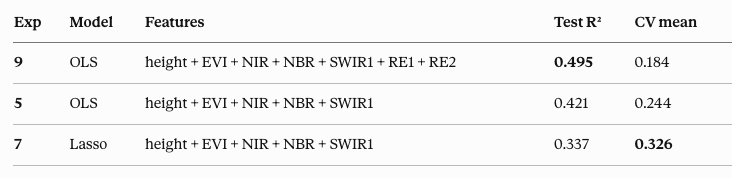

Exp 9 has the best test R² among honest models. Exp 7 has the best CV mean with tight std. The plot-level signal is real and stronger than the tree-level results (0.49 vs 0.28), which makes sense — plot averaging suppresses within-plot noise.

The consistent message: height_mean combined with a handful of spectral features is the right feature set. All-feature models are too many parameters for 59 plots.

In [ ]:
%run Model_functions.ipynb
tab_df = tabulate_results(lin_belige_plot_avg, acceptable_only=True)

### BELIGE. PLOT-AVEAGE. RANDOM FOREST {Hyperparameter tuning: NO}

In [ ]:
%run Model_functions.ipynb

rf_belige_avg_no_grid = {}

run_experiment(X_plot, y_plot,
               is_groups=False, group_info=grp_belige_avg,
               features_list=features_list_avg,
               experiments=rf_belige_avg_no_grid,
               model_type="rf",
               label = "Plot averages",
               is_grid=False,
               is_stratified=is_stratified_g,
               global_experiment_list=global_experiment_list)

In [ ]:
%run Model_functions.ipynb
tab_df = tabulate_results(rf_belige_avg_no_grid, acceptable_only=True)

**COMMENTS**  
Every experiment passes, and the numbers are substantially better than the tree-level RF (best was 0.300 grouped CV). Plot-level aggregation has genuinely improved the signal.

Exp 6 is the standout — test R² 0.710 and CV mean 0.641, both honest. Unlike the LR all-features experiments which collapsed (R² −1.8M), RF handles 18 features on 47 rows gracefully through its built-in feature subsampling. The CV std of 0.23 is acceptable given only 59 plots.

Exp 1 is remarkable on its own — height alone gives CV mean 0.306 and test R² 0.579 with the tightest CV std (0.127). A single feature explaining 58% of variance on a held-out test set is a strong result.

The low CV std in Exp 1 vs the wider std in Exps 2–6 suggests adding spectral features improves mean performance but introduces fold-to-fold variance — some folds benefit more than others from the spectral signal.

### BELIGE. PLOT-AVEAGE. RANDOM FOREST {Hyperparameter tuning: Yes}

In [ ]:
%run Model_functions.ipynb

rf_belige_avg_grid = {}

run_experiment(X_plot, y_plot,
               is_groups=False, group_info=grp_belige_avg,
               features_list=features_list_avg,
               experiments=rf_belige_avg_grid,
               model_type="rf",
               label = "Plot averages",
               is_grid=True,
               is_stratified=is_stratified_g,
               global_experiment_list=global_experiment_list)

In [ ]:
%run Model_functions.ipynb
tab_df = tabulate_results(rf_belige_avg_grid, acceptable_only=True)

**COMMENTS**  

Tuning had modest impact — test R² barely moved, CV mean improved slightly.  
The model was already well-behaved untuned.  
Exp 6 remains the best model with test R² 0.701 and CV mean 0.666.  

Two observations worth noting:
 - The last CV fold consistently scores 0.128–0.261 across all experiments. One fold is systematically harder than the others — likely the plots in that fold have unusual spectral characteristics or AGB values. Worth investigating which plots fall in that fold.
 - Exp 1 (height only) CV improved significantly from 0.306 to 0.423 after tuning with minimal test R² change — the tuned model generalises more consistently from height alone, which is a meaningful ecological result.

# BELIGE DATA. WITHOUT LOW VARIANCE ROWS

In [ ]:
%run Model_functions.ipynb

belige_var_df = sentinel_df[sentinel_df['dataset'] == 'Belige'].copy()
assert len(belige_var_df['simard_height_m'].head())
assert len(belige_var_df['tandemx_height_m'].head())

In [ ]:
belige_var_df = remove_low_variance_plots(belige_var_df, threshold=0.01).copy()

In [ ]:
X_belige_sub = belige_var_df[feature_cols].copy()

# Select TANDEMX
X_belige_sub = X_belige_sub.rename({'tandemx_height_m': 'height'}, axis=1)
X_belige_sub = X_belige_sub.drop(columns=['simard_height_m'])

y_belige_sub  = belige_var_df[target]

X_belige_sub.columns

## Interaction terms

In [ ]:
# height × EVI — the most promising. Height captures structural biomass, EVI captures canopy greenness.
# Their product approximates a "green volume" index and may capture the AGB signal better than either alone.
X_belige_sub['height_x_EVI'] = X_belige_sub['height'] * X_belige_sub['EVI']

#height × NIR — NIR reflectance is strongly tied to canopy density.
# Combined with height it approximates canopy biomass density.
X_belige_sub['height_x_NIR'] = X_belige_sub['height'] * X_belige_sub['NIR']

#height × NDRE1 — red-edge is sensitive to chlorophyll content.
# For mangroves, chlorophyll × height is a reasonable proxy for woody biomass.
X_belige_sub['height_x_NDRE1'] = X_belige_sub['height'] * X_belige_sub['NDRE1']

In [ ]:
X_belige_sub.columns

## Form groups

In [ ]:
%run Model_functions.ipynb

plot_groups_belige_sub = X_belige_sub['plot_id'].copy()
X_belige_sub           = X_belige_sub.drop(columns=['plot_id'])

near_zero_sites_sub, high_agb_sites_sub,\
    near_zero_plots_sub, high_agb_plots_sub = get_low_and_high_agb_plots(y_belige_sub,
                                                                         plot_groups_belige_sub)

site_groups_belige_sub = plot_groups_belige_sub.map(lambda x: x.rsplit('_', maxsplit=1)[0])

grp_belige_sub = GROUP_INFO(near_zero_sites_sub, high_agb_sites_sub,
                            near_zero_plots_sub, high_agb_plots_sub,
                            groups=plot_groups_belige_sub,
                            cv=test_cv)

### BELIGE WITHOUT LOW VARIANCE ROWS. PLOT GROUPS. LINEAR REGRESSION

In [ ]:
%run Model_functions.ipynb
lin_belige_subset_groups = {}

run_experiment(X_belige_sub, y_belige_sub,
               is_groups=True, group_info=grp_belige_sub,
               features_list=gen_features_list,
               experiments=lin_belige_subset_groups,
               model_type="linear",
               is_grid=False,
               is_stratified=is_stratified_g,
               global_experiment_list=global_experiment_list)

In [ ]:
%run Model_functions.ipynb
tab_df = tabulate_results(lin_belige_subset_groups, acceptable_only=True)

### BELIGE WITHOUT LOW VARIANCE ROWS. PLOT GROUPS. RANDOM FOREST. NO Grid

In [ ]:
%run Model_functions.ipynb

rf_belige_subset_no_grid_groups = {}

run_experiment(X_belige_sub, y_belige_sub,
               is_groups=True, group_info=grp_belige_sub,
               features_list=gen_features_list,
               experiments=rf_belige_subset_no_grid_groups,
               model_type="rf",
               is_grid=False,
               is_stratified=is_stratified_g,
               global_experiment_list=global_experiment_list)

In [ ]:
%run Model_functions.ipynb
tab_df = tabulate_results(rf_belige_subset_no_grid_groups, acceptable_only=True)

### BELIGE WITHOUT LOW VARIANCE ROWS. PLOT GROUPS. RANDOM FOREST. With Grid

In [ ]:
%run Model_functions.ipynb

rf_belige_subset_grid_groups = {}

run_experiment(X_belige_sub, y_belige_sub,
               is_groups=True, group_info=grp_belige_sub,
               features_list=gen_features_list,
               experiments=rf_belige_subset_grid_groups,
               model_type="rf",
               is_grid=True,
               is_stratified=is_stratified_g,
               global_experiment_list=global_experiment_list)

In [ ]:
tab_df = tabulate_results(rf_belige_subset_grid_groups, acceptable_only=True)

**COMMENTS**  
Removing low-variance rows does not destroy test performance on the same plots. But it degrades grouped CV generalisation because the training distribution no longer spans the full ecological range, making the model less reliable when evaluated against unseen high-AGB plots in cross-validation.  

**What IS genuinely hurt is the grouped CV**  
Every experiment now has unexplained negative folds at high-AGB sites — Channel Caye_4, Channel Caye_5, Big Creek_2, Big Creek_3.  
This is the real effect of removing low-variance rows: the CV assignment shifts to harder, higher-variance folds, and the model trained without near-zero AGB examples cannot generalise across them consistently.

# BEST MODEL LIST

## Summary of experiments.

In [ ]:
%run Model_functions.ipynb
best_results = filter_best_experiments(global_experiment_list, grouped_only=True)
tab_df = tabulate_results(best_results, grouped_only=True)

## Best model

In [ ]:
%run Model_functions.ipynb
best_result = best_results[0][1]
print_experiment(best_result)

### Residual analysis

In [ ]:
y_pred    = best_result["y_pred"]
residuals = best_result["residuals"]

residual_analysis(y_pred, residuals)